In [3]:
from src.config import *
from src.data_loader import *
from src.utils import *

In [59]:
%run src/data_loader.py

In [60]:
init_duckdb_views()

Created or replaced view: author
Created or replaced view: reason
Created or replaced view: retraction
Created or replaced view: retraction_author
Created or replaced view: retraction_reason
Created or replaced view: retraction_subject
Completed automatic creation of all views.


In [61]:
show_database_schema()

Table/View: author
  - author_id (VARCHAR)
  - author_name (VARCHAR)

Table/View: reason
  - reason_tag (VARCHAR)
  - reason_category (VARCHAR)

Table/View: retraction
  - doi (VARCHAR)
  - publication_date (TIMESTAMP_NS)
  - retraction_date (TIMESTAMP_NS)
  - journal (VARCHAR)
  - publisher (VARCHAR)
  - retraction_lag_days (BIGINT)

Table/View: retraction_author
  - doi (VARCHAR)
  - author_id (VARCHAR)
  - is_1st_author (BOOLEAN)
  - affiliation_country (VARCHAR)

Table/View: retraction_reason
  - doi (VARCHAR)
  - reason_tag (VARCHAR)

Table/View: retraction_subject
  - doi (VARCHAR)
  - subject (VARCHAR)

Completed displaying database schema information.


In [5]:
retraction_by_authorship_sql = load_yaml_file(SQL_DIR / "year-wise-pattern.yaml").get("sql")
retraction_by_authorship = execute_sql_to_df(retraction_by_authorship_sql)
retraction_by_authorship

,retraction_year,1 author,2 authors,3 authors,4+ authors
0,2021,5,2,0,1
1,2022,36,23,13,7
2,2023,124,84,43,24
3,2024,22,14,8,6
4,2025,9,6,5,3
5,2026,9,5,1,0


Done


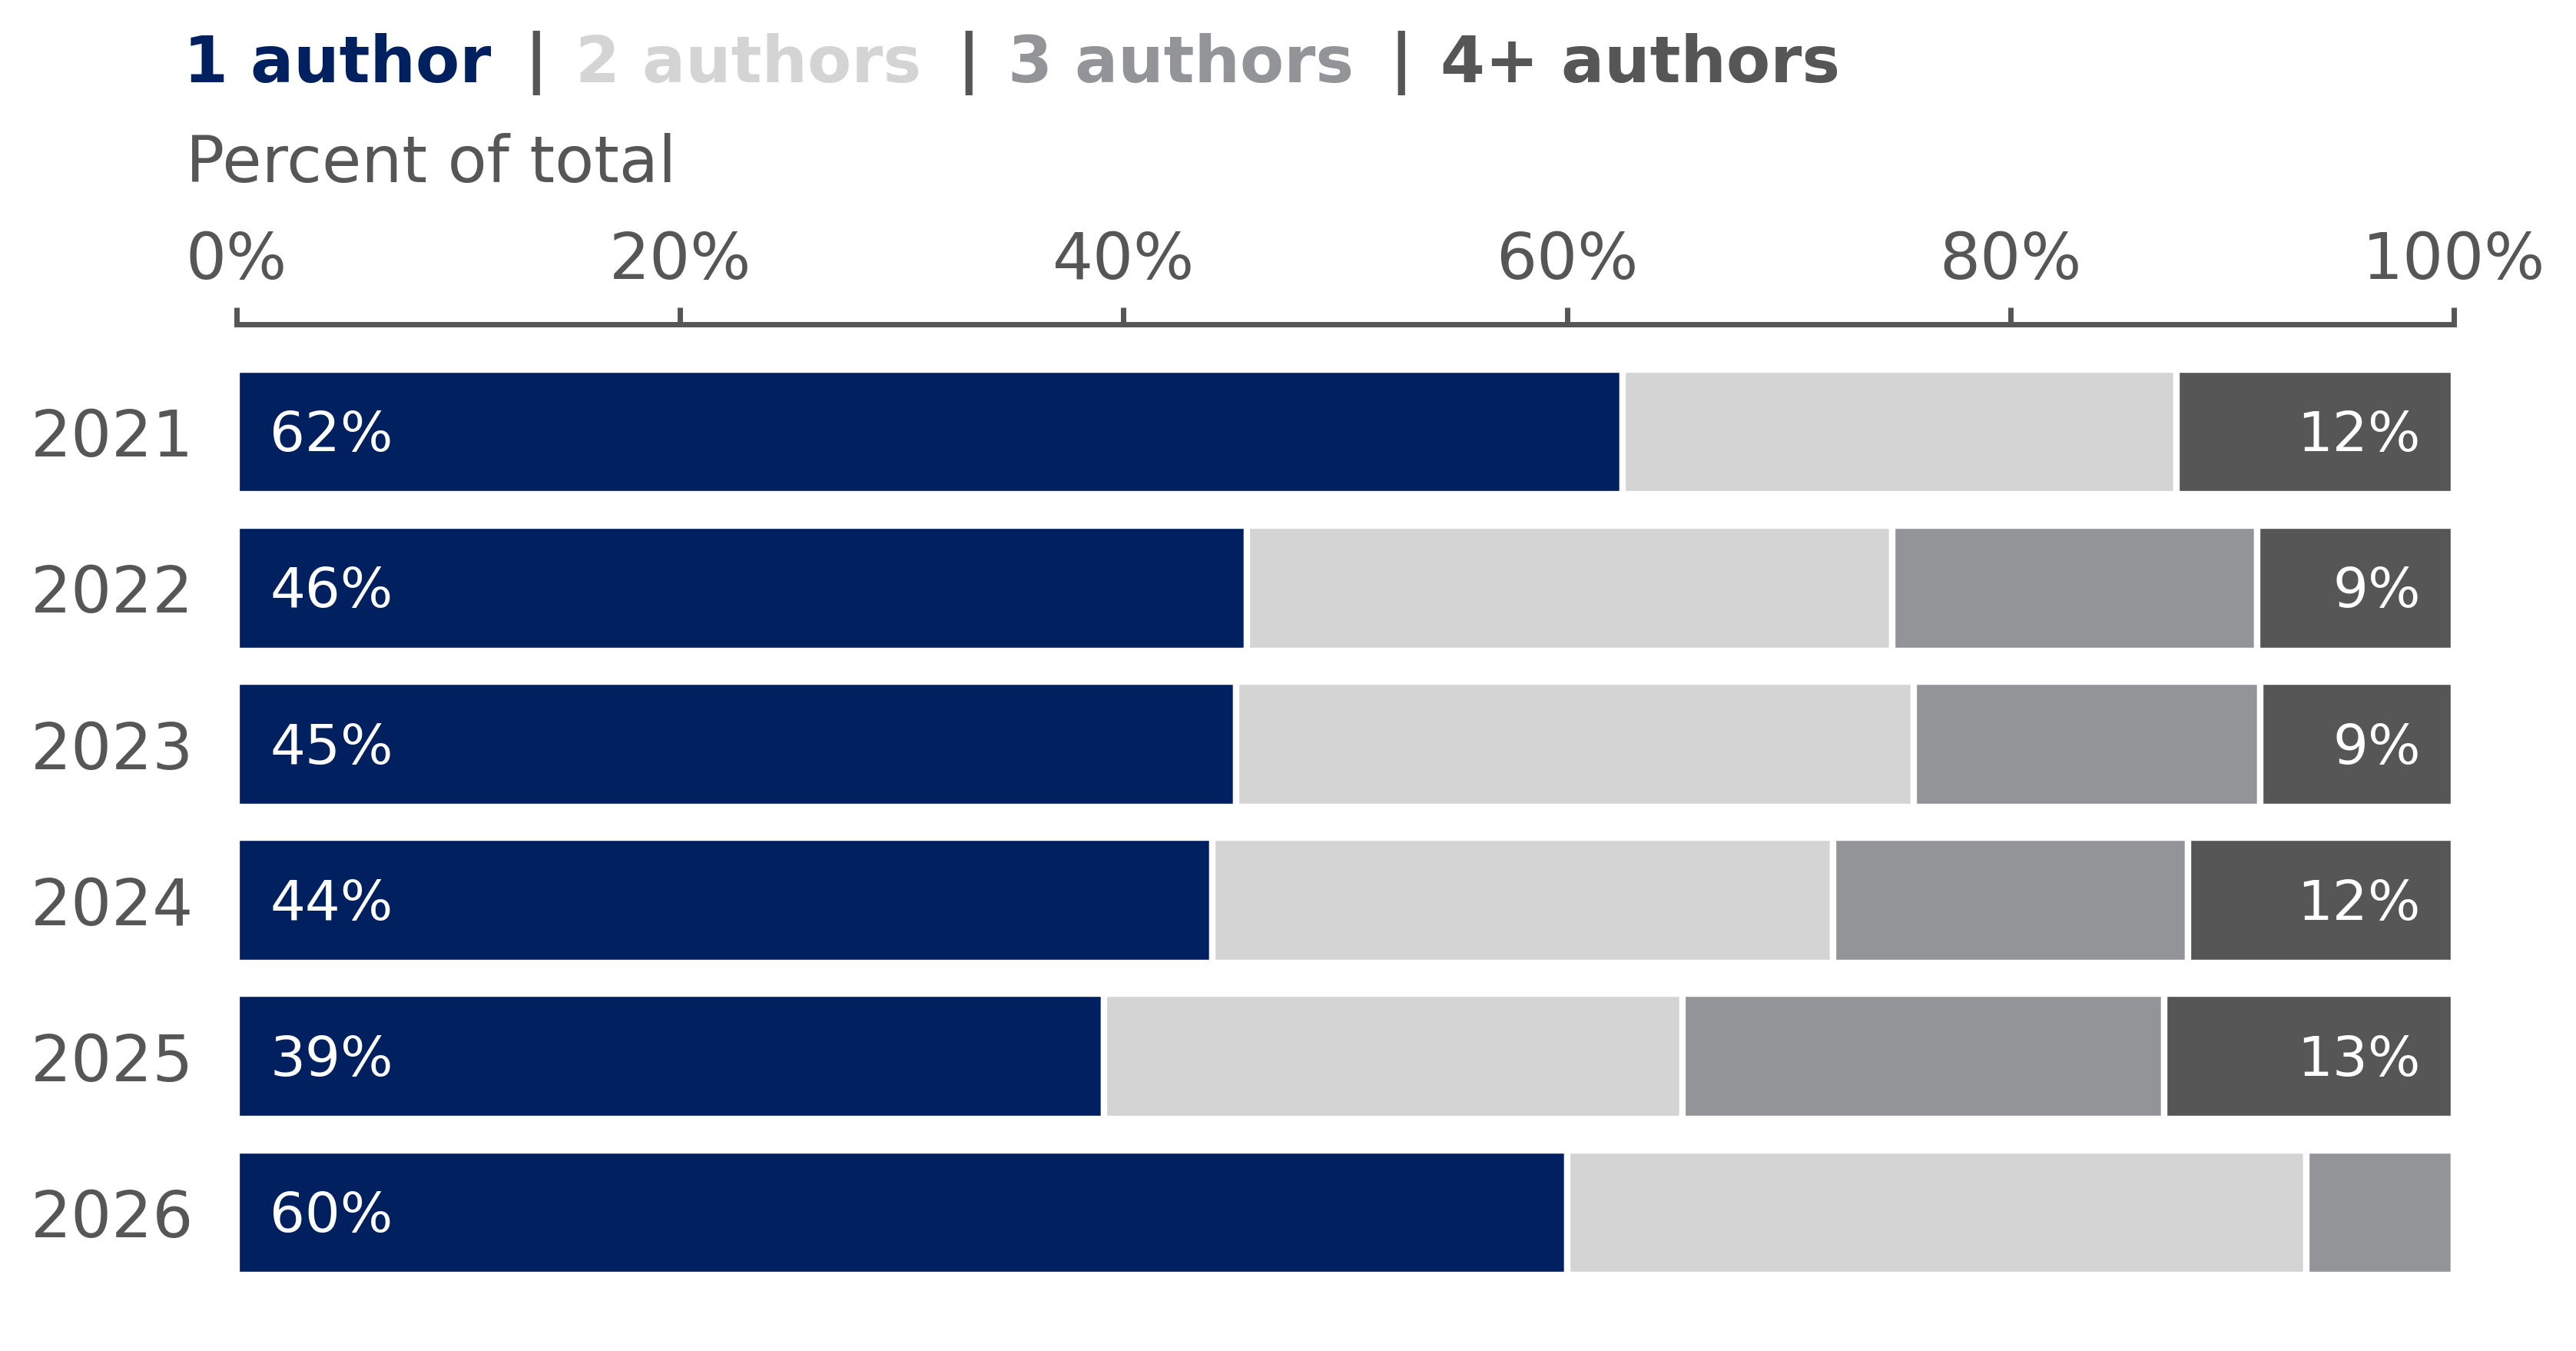

In [6]:
%run src/plotting_styles.py
%run src/plots/year-wise-pattern.py

fig, ax = render_authorship_distribution_chart(
    df=retraction_by_authorship,
    palette=PALETTE,
)

plt.show()

In [7]:
retraction_by_year_sql = load_yaml_file(SQL_DIR / "volume-by-year.yaml").get("sql")
retraction_by_year = execute_sql_to_df(retraction_by_year_sql)
retraction_by_year

,retraction_year,retraction_count
0,2021,9
1,2022,82
2,2023,307
3,2024,61
4,2025,26
5,2026,16


Done


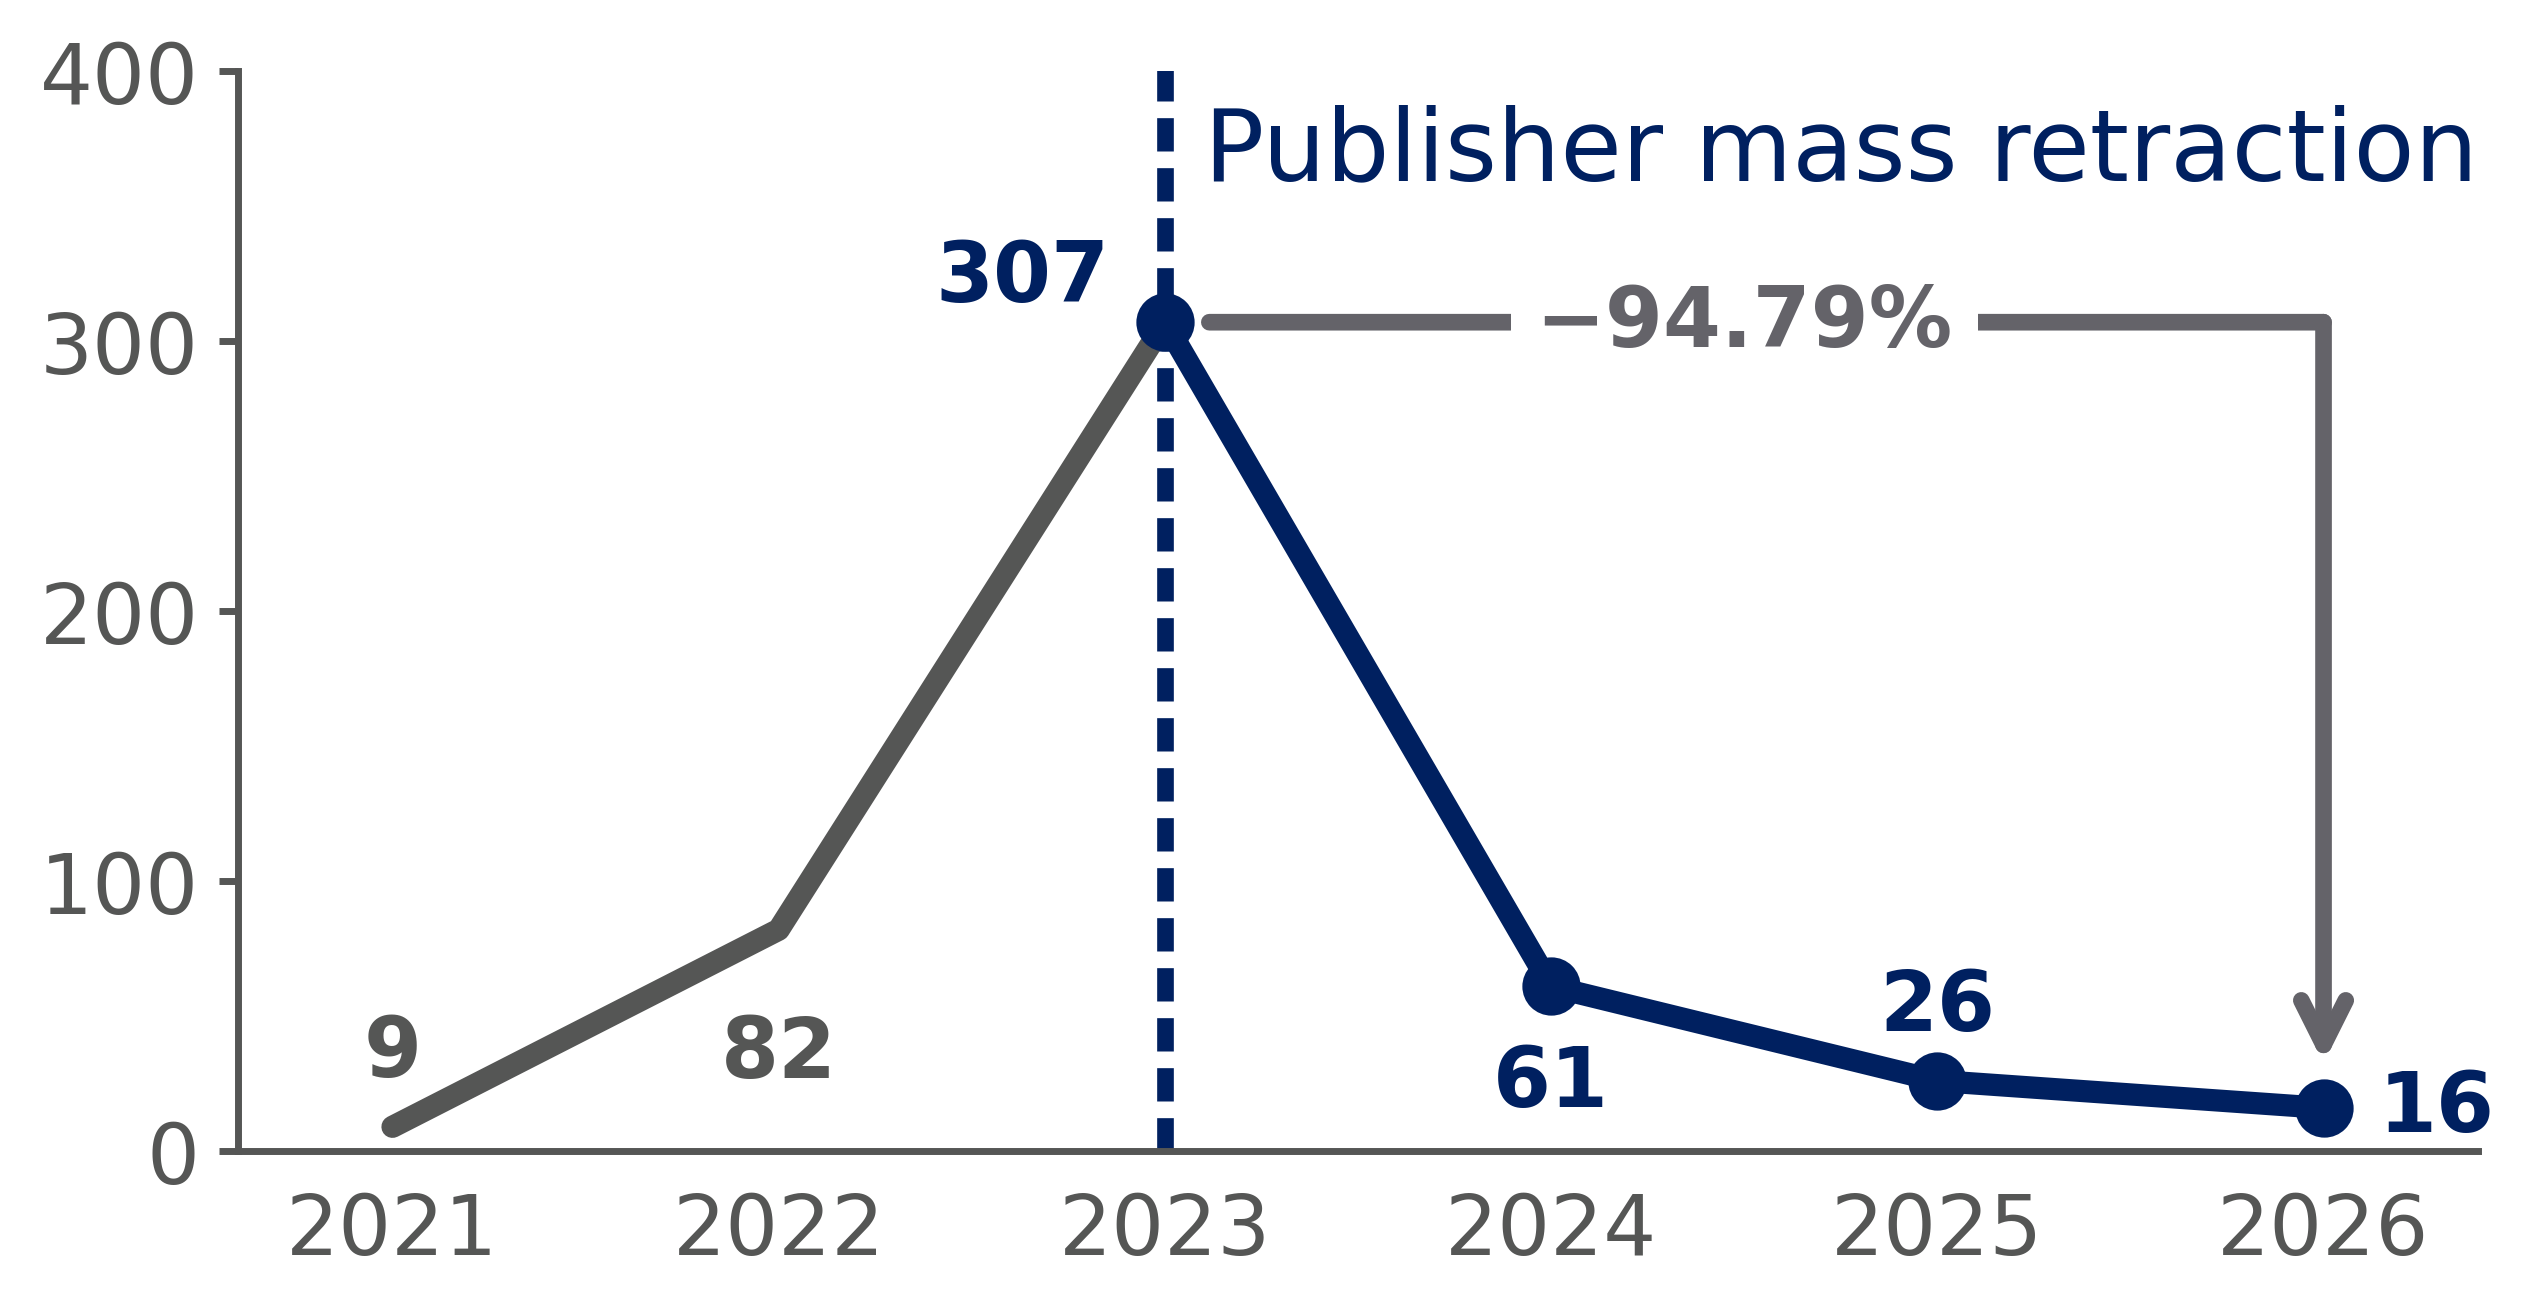

In [8]:
%run src/plotting_styles.py
%run src/plots/volume-by-year.py

fig, ax = render_retraction_chart(
    retraction_by_year,
    palette=PALETTE,
    annotation_positions=ANNOTATION_POSITIONS
)
plt.show()

In [38]:
retraction_by_subject_sql = load_yaml_file(SQL_DIR / "top-5-subjects-ranking.yaml").get("sql")
retraction_by_subject = execute_sql_to_df(retraction_by_subject_sql)
retraction_by_subject

,subject,total_count,count_2023,count_excluding_2023
0,Technology,333,208,125
1,Data Science,230,164,66
2,Computer Science,219,118,101
3,Education,130,84,46
4,Business - Management,104,65,39
5,Others,482,331,151


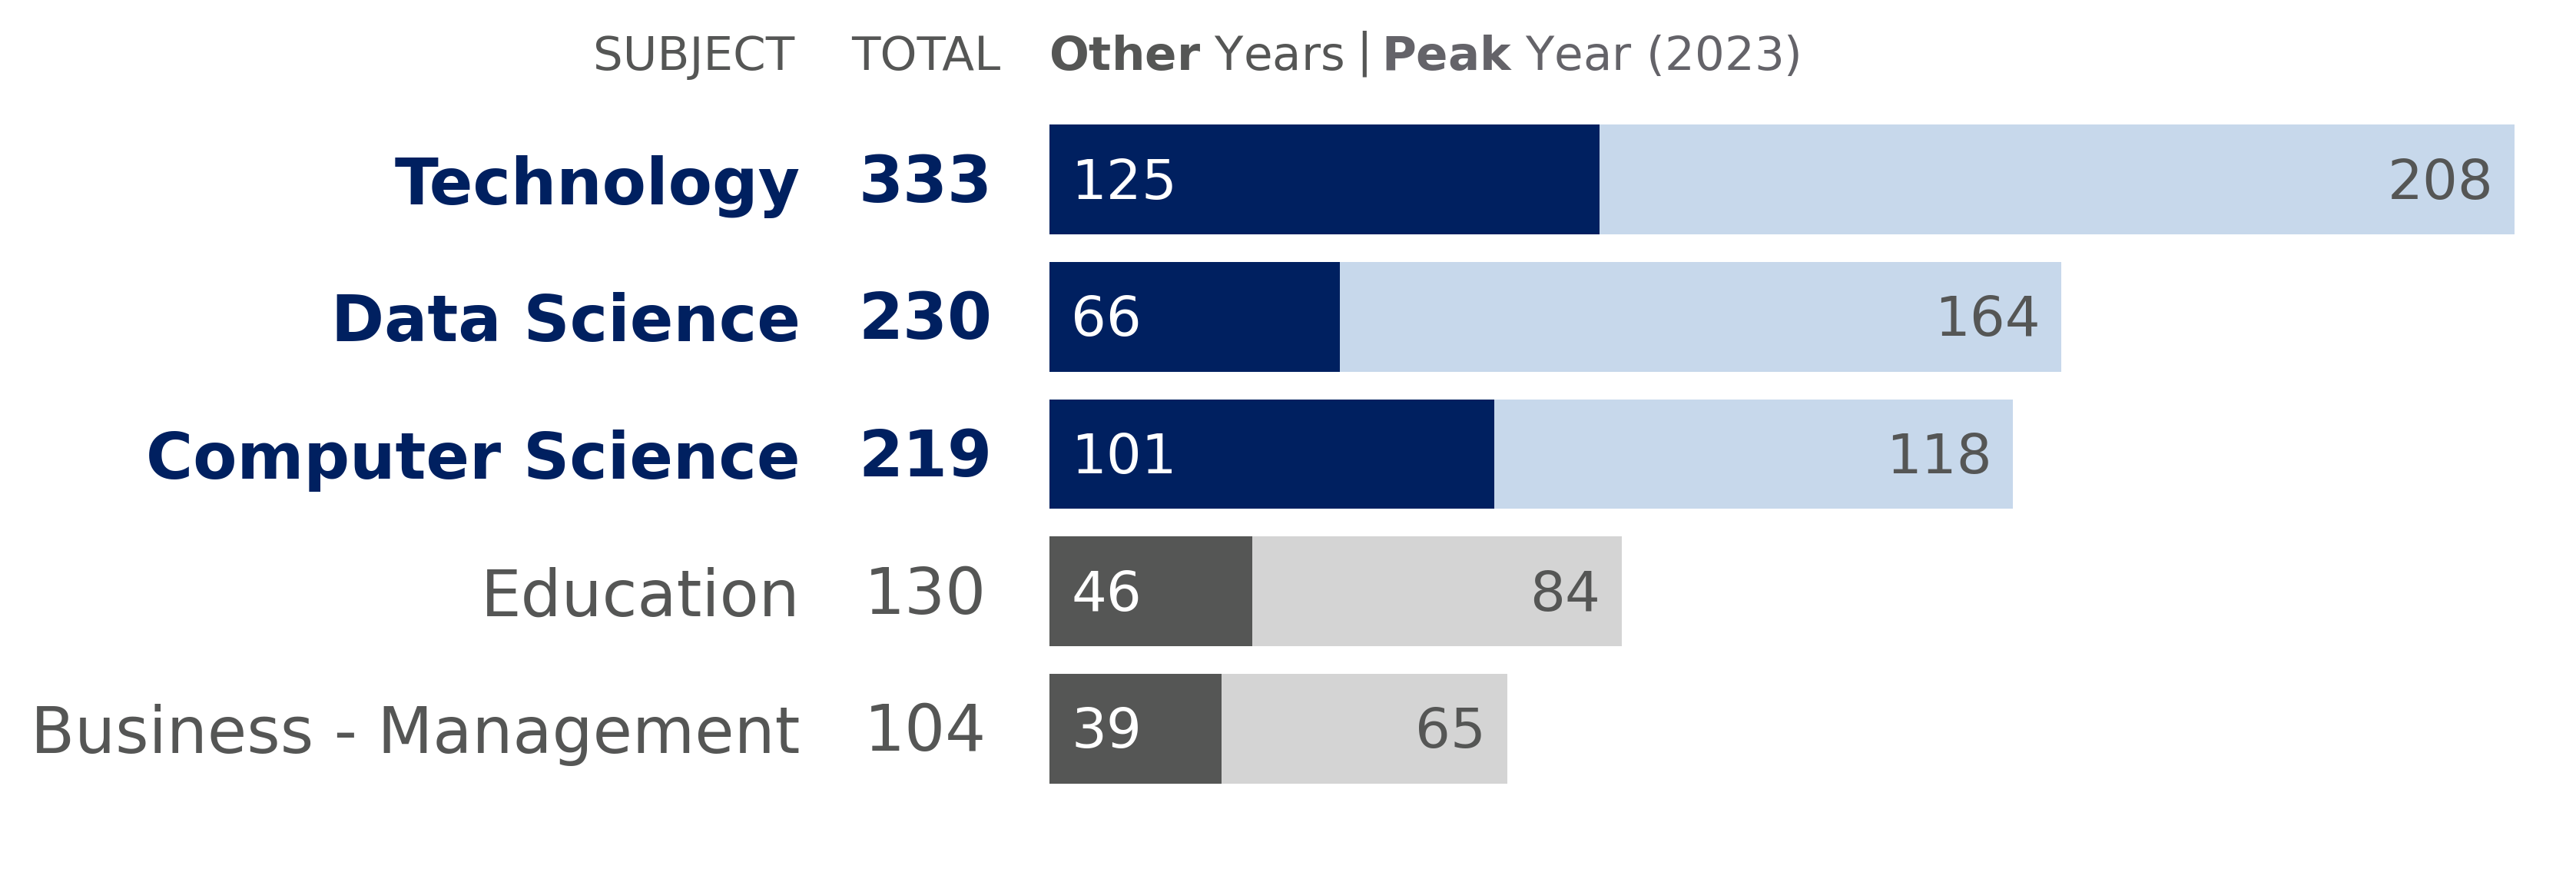

In [43]:
%run src/plotting_styles.py
%run src/plots/top-5-subjects-ranking.py

fig, ax = render_retraction_subject_chart(
    df=retraction_by_subject.head(5),
    palette=PALETTE,
)

plt.show()

In [44]:
retraction_by_journal_sql = load_yaml_file(SQL_DIR / "top-5-journals-ranking.yaml").get("sql")
retraction_by_journal = execute_sql_to_df(retraction_by_journal_sql)
retraction_by_journal

,journal,total_count,count_2023,count_excluding_2023
0,Security and Communication Networks,63,52,11
1,Wireless Communications and Mobile Computing,45,45,0
2,Journal of Healthcare Engineering,33,32,1
3,Computational Intelligence and Neuroscience,33,32,1
4,Soft Computing,28,1,27
5,Others,299,145,154


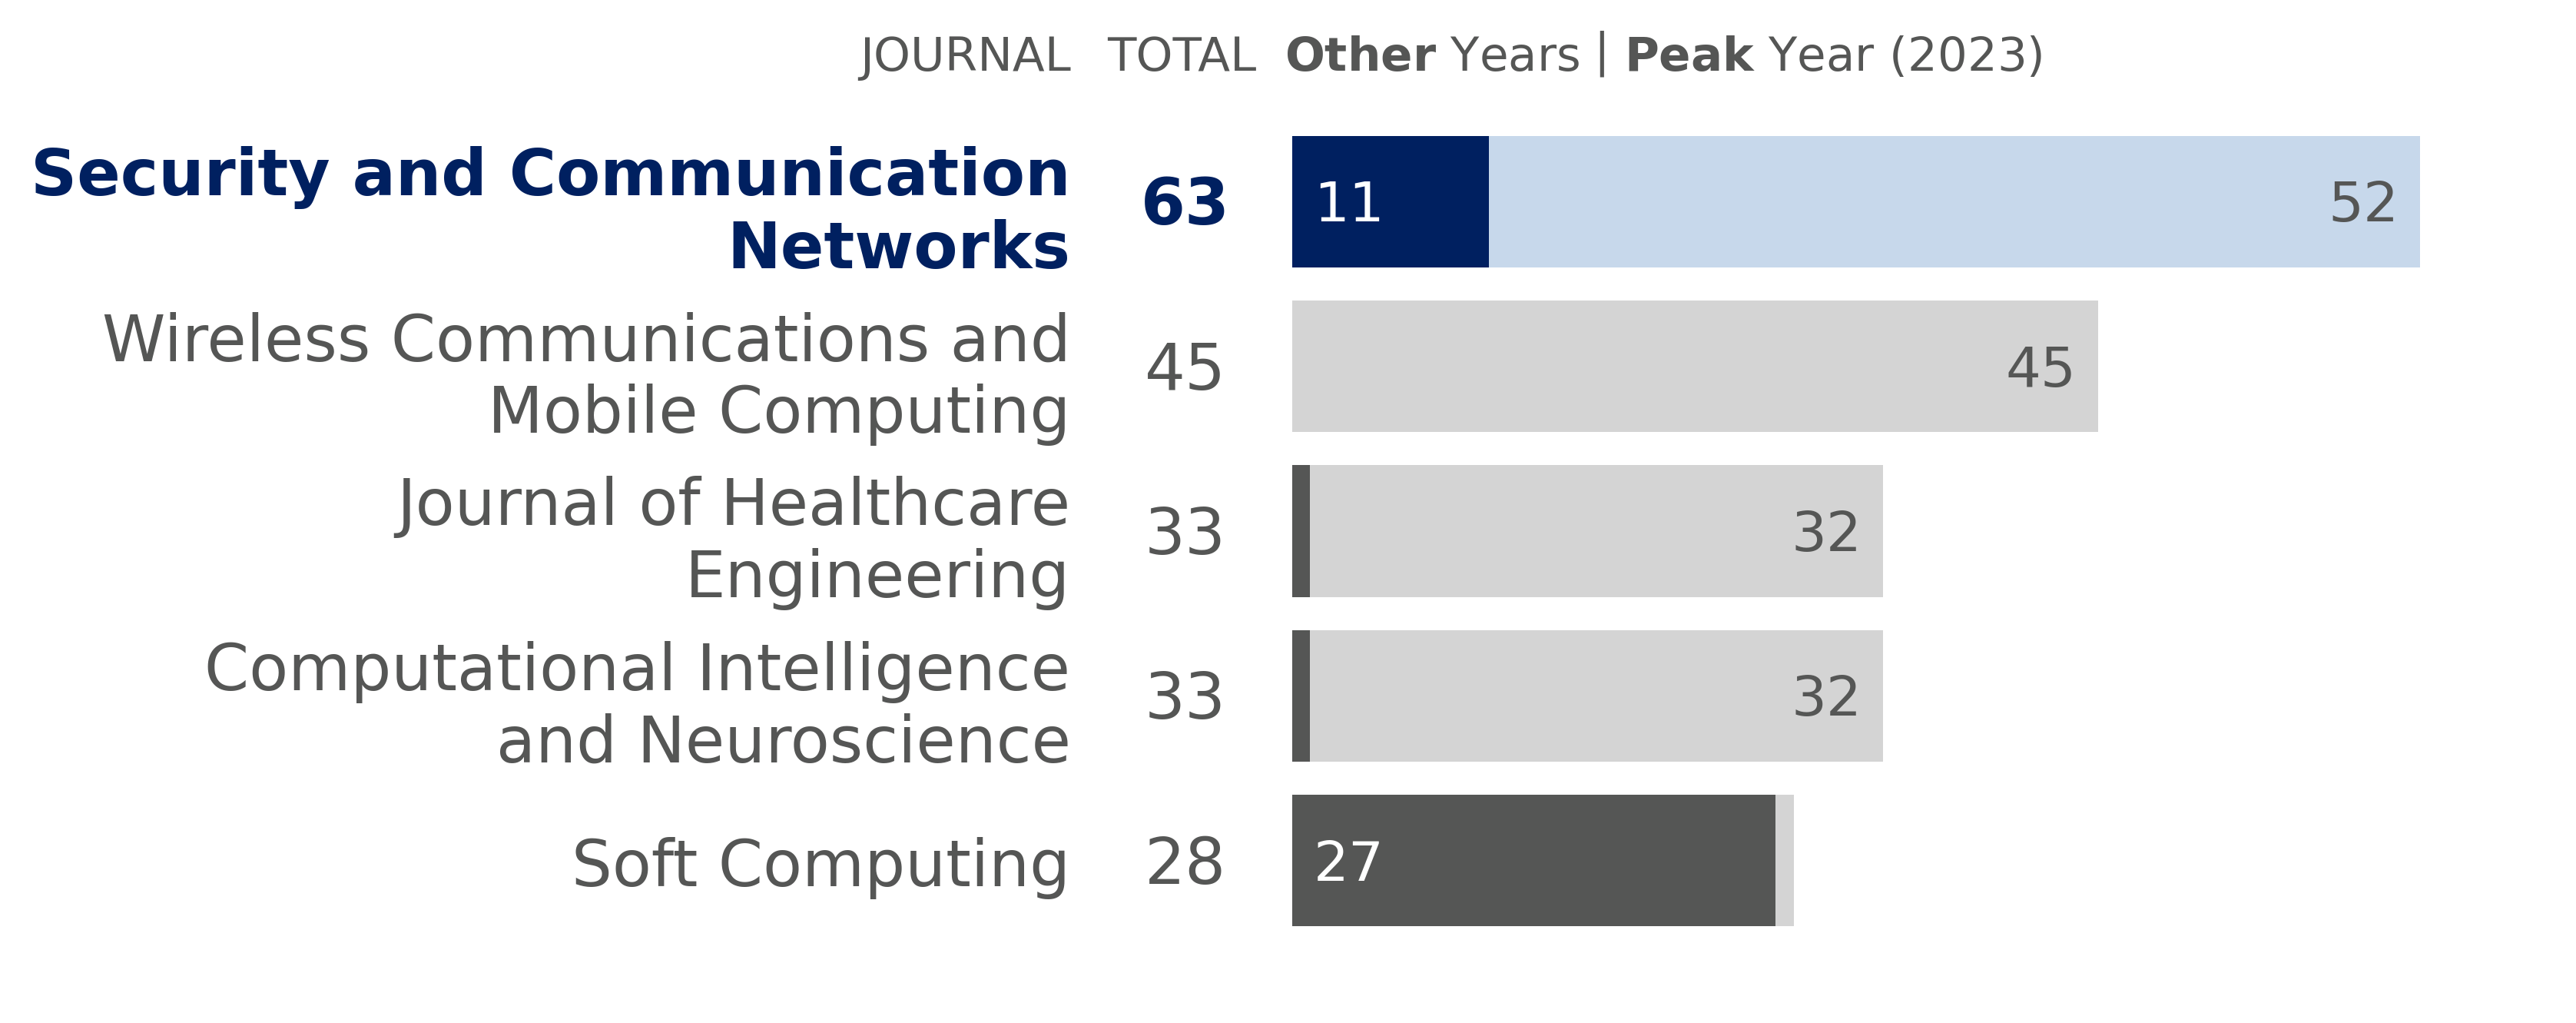

In [48]:
%run src/plotting_styles.py
%run src/plots/top-5-journals-ranking.py

fig, ax = render_retraction_journal_chart(
    df=retraction_by_journal.head(5),
    palette=PALETTE,
)

plt.show()

In [50]:
retraction_by_publisher_sql = load_yaml_file(SQL_DIR / "top-5-publishers-ranking.yaml").get("sql")
retraction_by_publisher = execute_sql_to_df(retraction_by_publisher_sql)
retraction_by_publisher

,publisher,total_count,count_2023,count_excluding_2023
0,Hindawi,345,301,44
1,Springer - Nature Publishing Group,39,0,39
2,IOS Press (bought by Sage November 2023),25,0,25
3,IOP Publishing,23,1,22
4,Association for Computing Machinery (ACM),23,0,23
5,Others,46,5,41


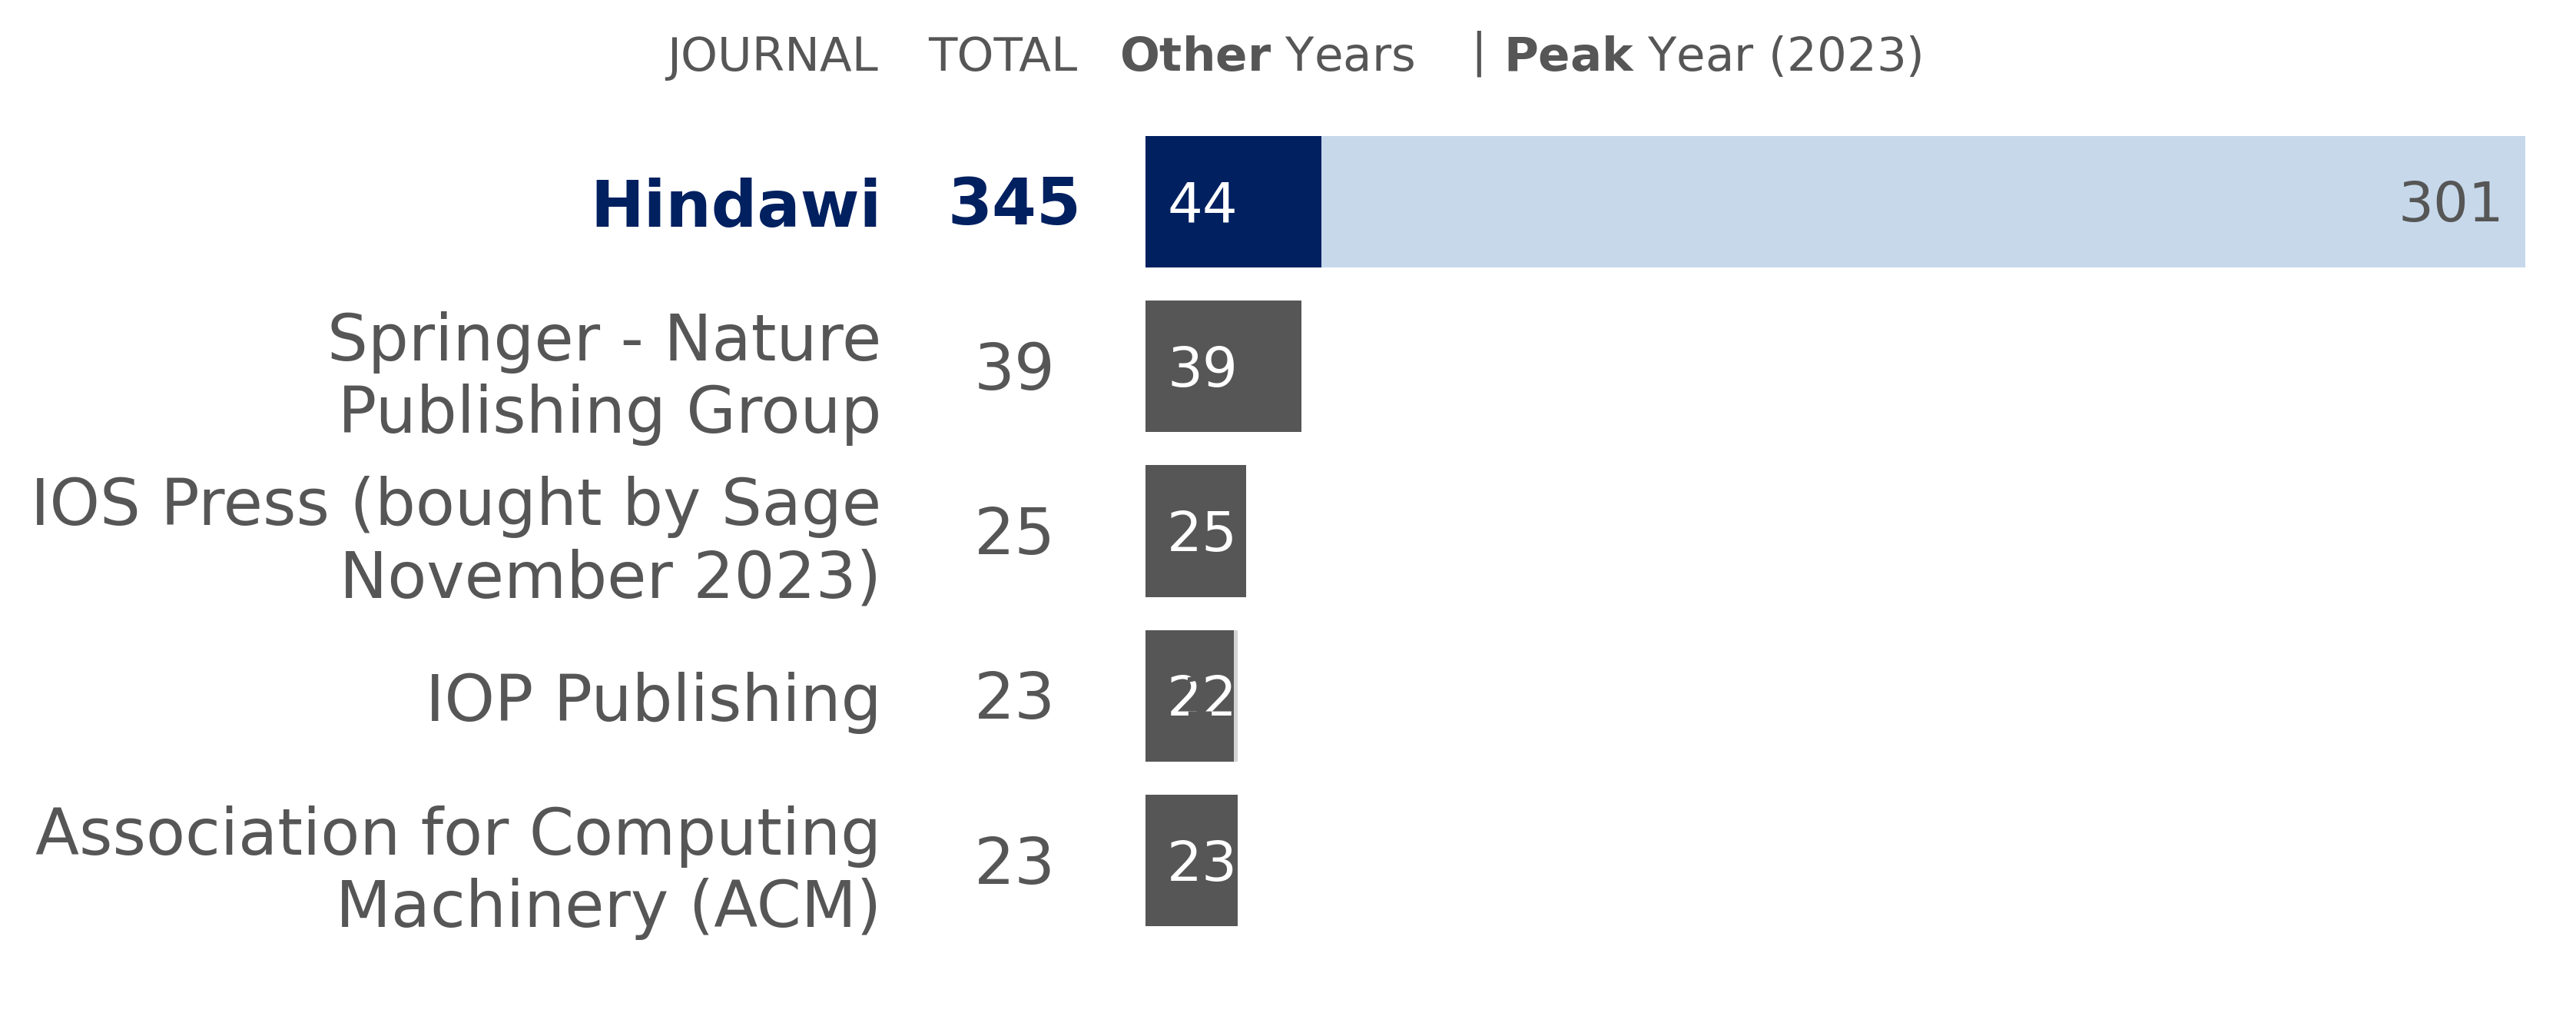

In [56]:
%run src/plotting_styles.py
%run src/plots/top-5-publishers-ranking.py

fig, ax = render_retraction_publisher_chart(
    df=retraction_by_publisher.head(5),
    palette=PALETTE,
)

In [68]:
retraction_by_reason_sql = load_yaml_file(SQL_DIR / "top-10-reasons-ranking.yaml").get("sql")
retraction_by_reason = execute_sql_to_df(retraction_by_reason_sql)
retraction_by_reason

,reason,total_count,count_2023,count_excluding_2023
0,Investigation by Journal/Publisher,487,305,182
1,Unreliable Results and/or Conclusions,397,297,100
2,Investigation by Third Party,343,283,60
3,Concerns/Issues about Referencing/Attributions,335,245,90
4,Concerns/Issues about Peer Review,312,250,62
5,Concerns/Issues about Data,276,243,33
6,Paper Mill,260,196,64
7,Computer-Aided Content or Computer-Generated C...,251,194,57
8,Concerns/Issues about Results and/or Conclusions,237,204,33
9,Compromised Peer Review,188,55,133


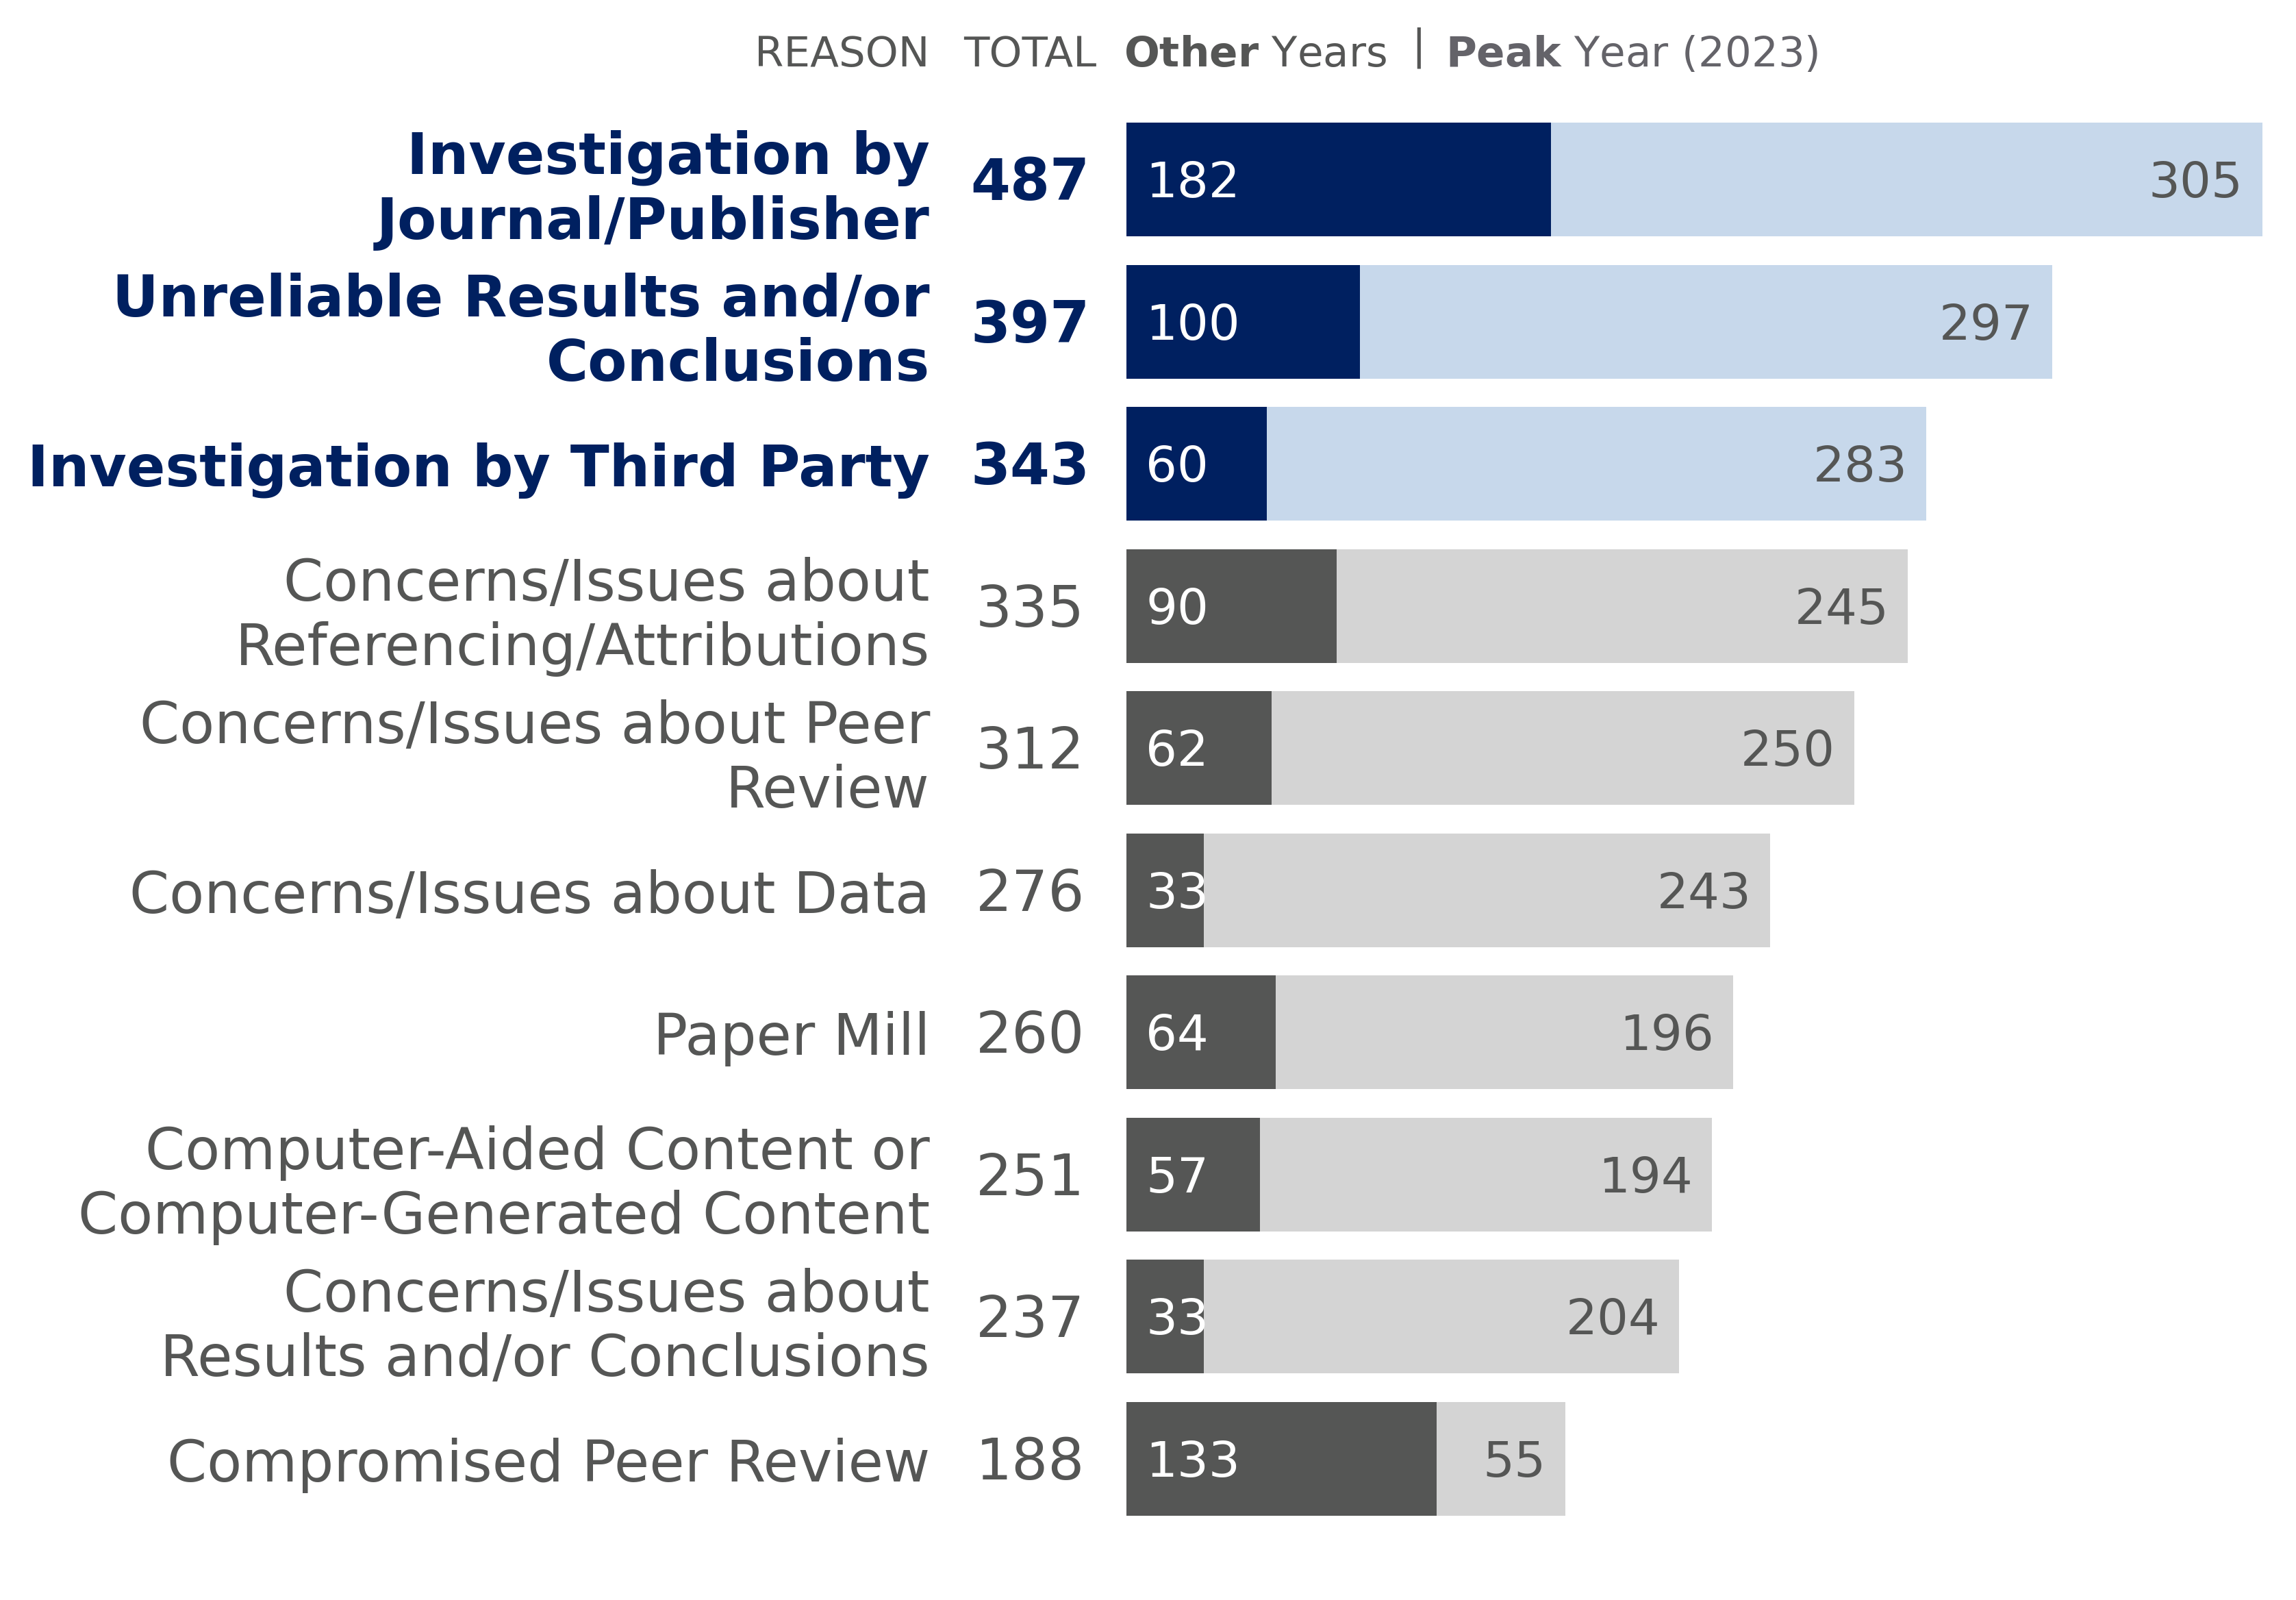

In [80]:
%run src/plotting_styles.py
%run src/plots/top-10-reasons-ranking.py

fig, ax = render_retraction_reason_chart(
    df=retraction_by_reason.head(10),
    palette=PALETTE,
)

In [85]:
pip install networkx


   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
    --------------------------------------- 0.0/2.1 MB 259.2 kB/s eta 0:00:08
   - -------------------------------------- 0.1/2.1 MB 363.1 kB/s eta 0:00:06
   - -------------------------------------- 0.1/2.1 MB 476.3 kB/s eta 0:00:05
   -- ------------------------------------- 0.2/2.1 MB 610.0 kB/s eta 0:00:04
   --- ------------------------------------ 0.2/2.1 MB 654.4 kB/s eta 0:00:03
   ---- ----------------------------------- 0.2/2.1 MB 684.7 kB/s eta 0:00:03
   ----- ---------------------------------- 0.3/2.1 MB 791.9 kB/s eta 0:00:03
   ------- -------------------------------- 0.4/2.1 MB 897.8 kB/s eta 0:00:02
   ------- -------------------------------- 0.4/2.1 MB 888.4 kB/s eta 0:00:02
   ------- -------------------------------- 0.4/2.1 MB 888.4 kB/s eta 0:00:02
   ------- -


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [158]:
reasons_cooccurrence_sql = load_yaml_file(SQL_DIR / "reasons-cooccurrence.yaml").get("sql")
reasons_cooccurrence = execute_sql_to_df(reasons_cooccurrence_sql)
reasons_cooccurrence

,reason_a,reason_b,freq_a,freq_b,"round(sqrt(c.freq_overlap), 1)",weight
0,Investigation by Journal/Publisher,Unreliable Results and/or Conclusions,22.1,19.9,19.7,0.886787
1,Investigation by Journal/Publisher,Investigation by Third Party,22.1,18.5,18.5,0.836493
2,Concerns/Issues about Referencing/Attributions,Investigation by Journal/Publisher,18.3,22.1,18.2,0.815963
3,Concerns/Issues about Referencing/Attributions,Unreliable Results and/or Conclusions,18.3,19.9,18.1,0.903424
4,Investigation by Third Party,Unreliable Results and/or Conclusions,18.5,19.9,18.1,0.893657
...,...,...,...,...,...,...
185,Concerns/Issues about Referencing/Attributions,Upgrade/Update of Prior Notice(s),18.3,3.0,1.0,0.018215
186,Concerns/Issues about Article,Investigation by Third Party,3.5,18.5,1.0,0.015444
187,Author Unresponsive,Paper Mill,4.2,16.1,1.0,0.014789
188,Concerns/Issues about Data,Concerns/Issues about Third Party Involvement,16.6,4.6,1.0,0.013096


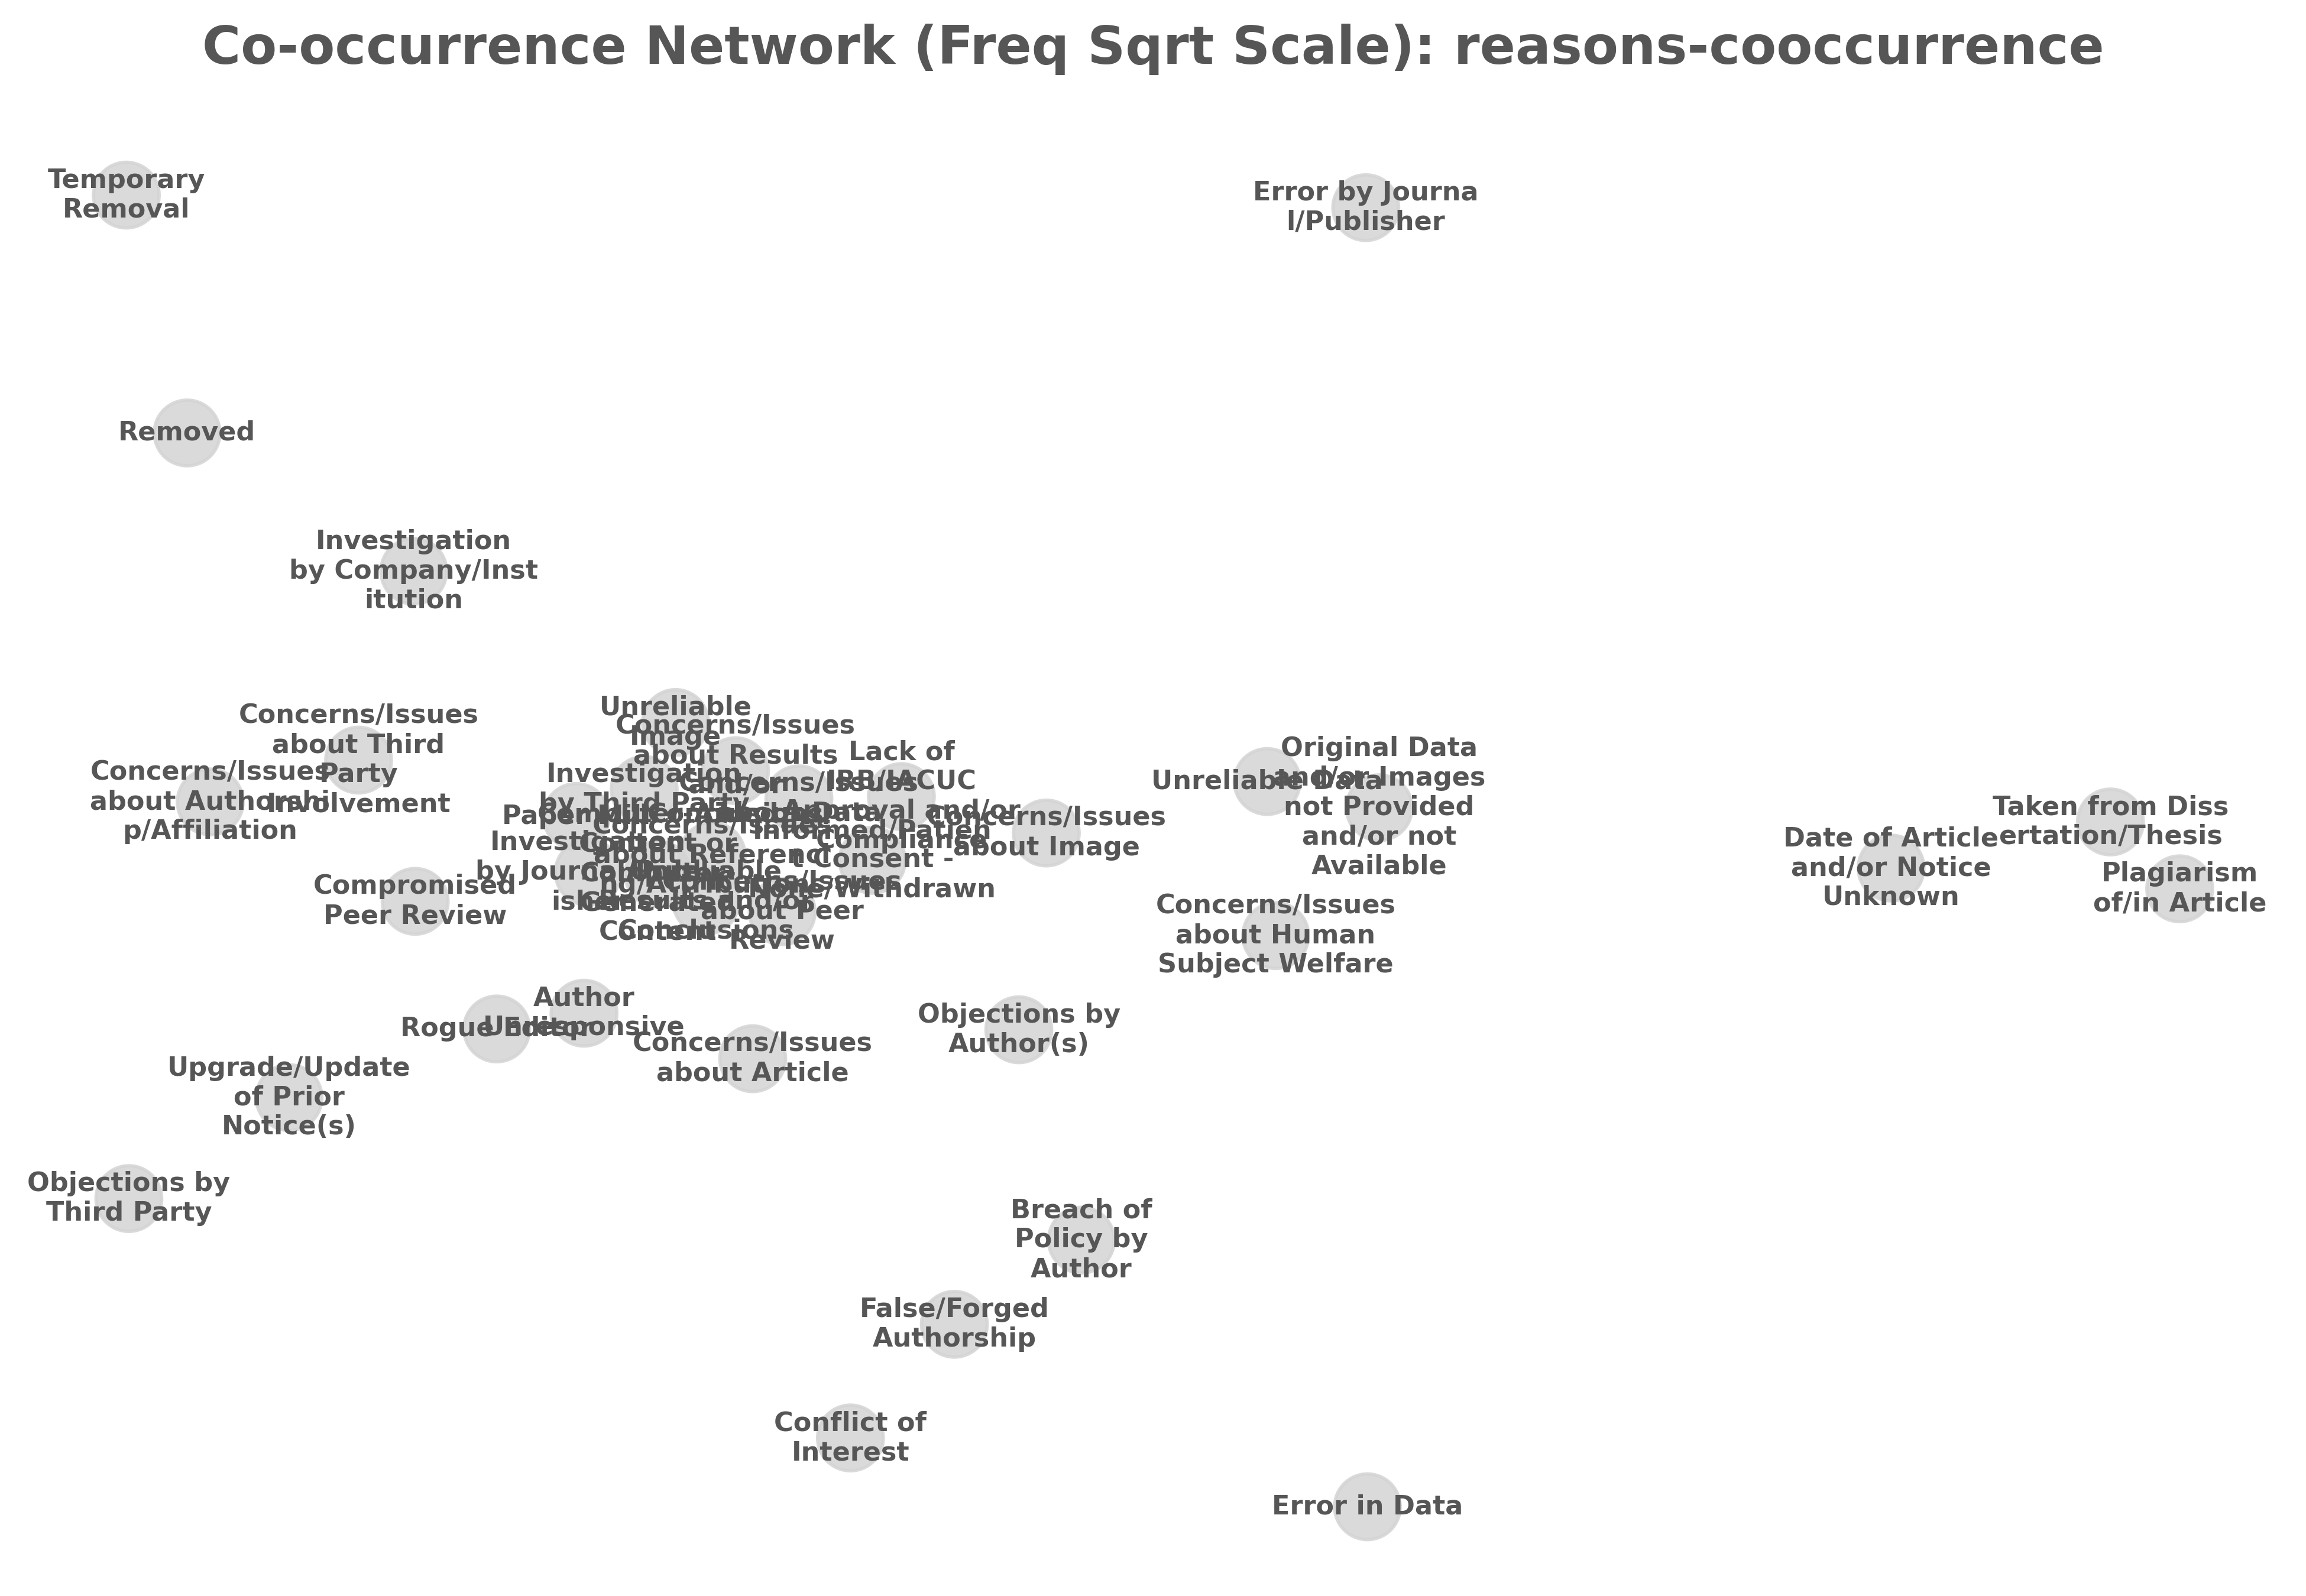

In [165]:
%run src/plotting_styles.py
%run src/plots/reasons-cooccurrence.py

plot_cooccurrence_network(
     df=reasons_cooccurrence, 
     model_name="reasons-cooccurrence", 
     palette=PALETTE, 
     min_weight=0.05
)